In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

INPUT_PATHS = ["sales_2023.csv","sales_2024.csv","sales_2025.csv","sales_2026.csv"]
con = duckdb.connect()
union_sql = " UNION ALL ".join([f"SELECT * FROM read_csv_auto('{p}')" for p in INPUT_PATHS])
con.execute(f"CREATE OR REPLACE TABLE sales AS {union_sql}")

def show_query_block(title, nlq, sql):
    display(Markdown(f"## {title}"))
    display(Markdown(f"**Natural Language Question:** {nlq}"))
    display(Markdown("**SQL Query:**"))
    display(Markdown(f"```sql\n{sql}\n```"))

def run_query(sql):
    df = con.execute(sql).df()
    display(df.head(20))
    return df

def plot_result(df, kind="bar", x=None, y=None, title=None, bins=25):
    if df.empty:
        print("No rows to plot."); return
    plt.figure(figsize=(10,4))
    if kind == "bar":
        plt.bar(df[x].astype(str), df[y]); plt.xlabel(x); plt.ylabel(y)
    elif kind == "line":
        plt.plot(df[x].astype(str), df[y], marker="o"); plt.xlabel(x); plt.ylabel(y)
    elif kind == "hist":
        plt.hist(df[x], bins=bins); plt.xlabel(x); plt.ylabel("count")
    plt.title(title if title else "")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

def insight(lines):
    md = "\n".join([f"- {line}" for line in lines])
    display(Markdown(f"**Business Insight:**\n{md}"))

print(con.execute("SELECT COUNT(*) AS total_rows FROM sales").df())

   total_rows
0     1000000


## 1. GROUP BY — Monthly Sales

**Natural Language Question:** What is the total sales amount by month across all years?

**SQL Query:**

```sql
SELECT EXTRACT(MONTH FROM transaction_date) AS sale_month, SUM(sales_amount) AS total_sales FROM sales GROUP BY sale_month ORDER BY sale_month;
```

,sale_month,total_sales
0,1,410628198.0
1,2,428817185.0
2,3,562632268.0
3,4,171351298.0
4,5,169175945.0
5,6,170278263.0
6,7,169574144.0
7,8,170721524.0
8,9,170027988.0
9,10,192918141.0


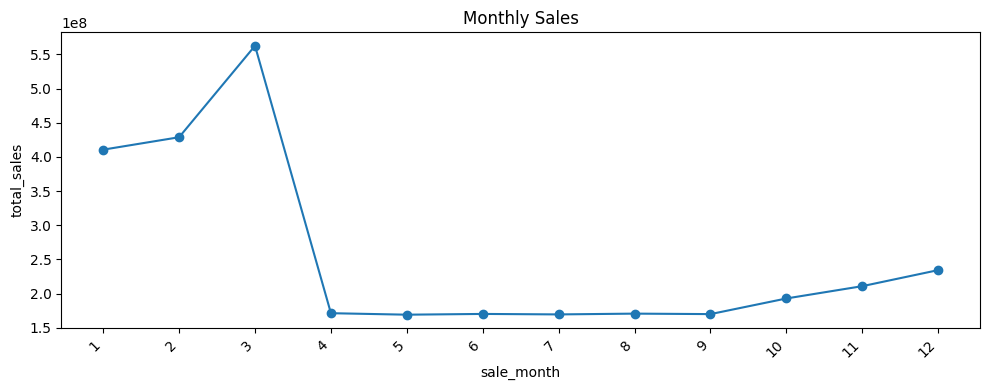

**Business Insight:**
- Monthly sales show seasonality and calendar effects.
- This helps identify stronger and weaker months for planning.

In [2]:
title = '1. GROUP BY — Monthly Sales'
nlq = 'What is the total sales amount by month across all years?'
sql = '''SELECT EXTRACT(MONTH FROM transaction_date) AS sale_month, SUM(sales_amount) AS total_sales FROM sales GROUP BY sale_month ORDER BY sale_month;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
plot_result(df, kind='line', x='sale_month', y='total_sales', title='Monthly Sales')
insight(['Monthly sales show seasonality and calendar effects.', 'This helps identify stronger and weaker months for planning.'])

## 2. GROUP BY — Yearly Sales

**Natural Language Question:** What is the total sales amount by year?

**SQL Query:**

```sql
SELECT EXTRACT(YEAR FROM transaction_date) AS sale_year, SUM(sales_amount) AS total_sales FROM sales GROUP BY sale_year ORDER BY sale_year;
```

,sale_year,total_sales
0,2023,2.978979e+08
1,2024,6.020250e+08
2,2025,1.226767e+09
3,2026,9.347635e+08


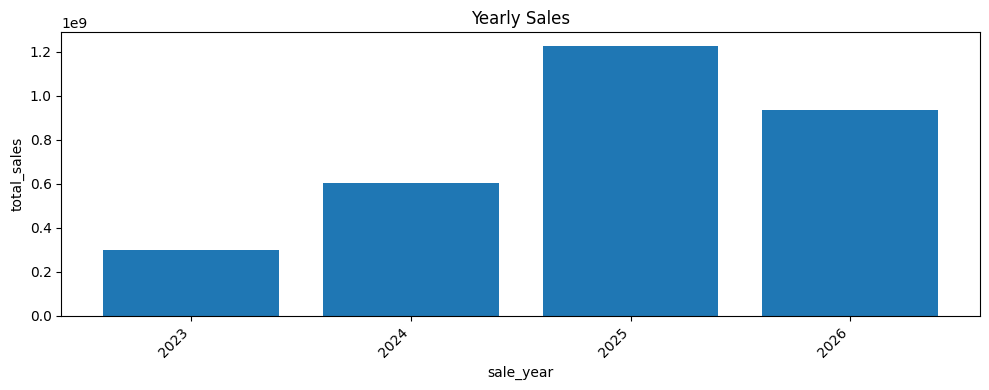

**Business Insight:**
- Yearly growth validates whether the business is expanding over time.
- This is a foundational KPI for executive reporting.

In [3]:
title = '2. GROUP BY — Yearly Sales'
nlq = 'What is the total sales amount by year?'
sql = '''SELECT EXTRACT(YEAR FROM transaction_date) AS sale_year, SUM(sales_amount) AS total_sales FROM sales GROUP BY sale_year ORDER BY sale_year;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
plot_result(df, kind='bar', x='sale_year', y='total_sales', title='Yearly Sales')
insight(['Yearly growth validates whether the business is expanding over time.', 'This is a foundational KPI for executive reporting.'])

## 3. GROUP BY — Sales by Country

**Natural Language Question:** How much sales amount comes from each country?

**SQL Query:**

```sql
SELECT country, SUM(sales_amount) AS total_sales FROM sales GROUP BY country ORDER BY total_sales DESC;
```

,country,total_sales
0,USA,1.039580e+09
1,INDIA,3.679361e+08
2,CHINA,3.658925e+08
3,GERMANY,3.060310e+08
4,CANADA,2.440360e+08
5,MEXICO,2.153727e+08
6,ITALY,1.852818e+08
7,FRANCE,1.832362e+08
8,SPAIN,1.540876e+08


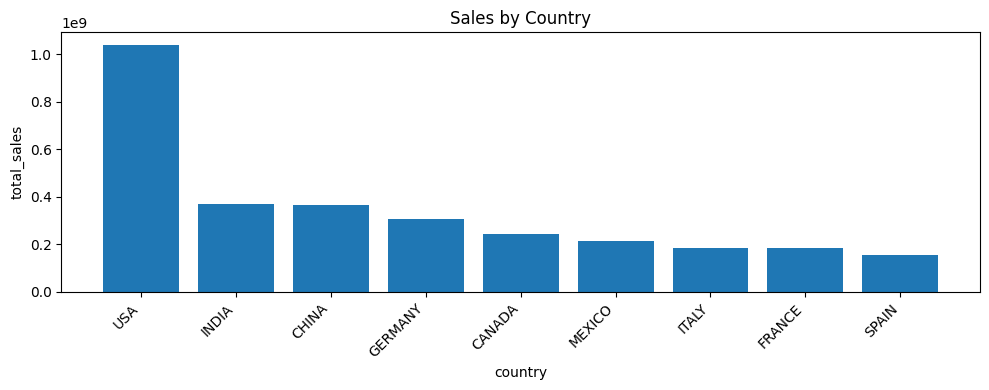

**Business Insight:**
- USA should dominate because the dataset was designed that way.
- Country ranking helps prioritize markets and sales strategy.

In [4]:
title = '3. GROUP BY — Sales by Country'
nlq = 'How much sales amount comes from each country?'
sql = '''SELECT country, SUM(sales_amount) AS total_sales FROM sales GROUP BY country ORDER BY total_sales DESC;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
plot_result(df, kind='bar', x='country', y='total_sales', title='Sales by Country')
insight(['USA should dominate because the dataset was designed that way.', 'Country ranking helps prioritize markets and sales strategy.'])

## 4. GROUP BY — Sales by Gender

**Natural Language Question:** How much sales amount comes from each gender group?

**SQL Query:**

```sql
SELECT gender, SUM(sales_amount) AS total_sales FROM sales GROUP BY gender ORDER BY total_sales DESC;
```

,gender,total_sales
0,FEMALE,1.912398e+09
1,MALE,1.149056e+09


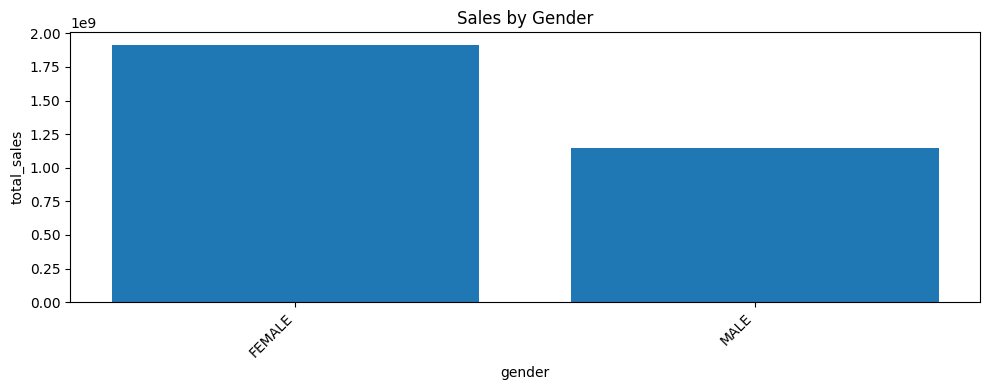

**Business Insight:**
- A higher female volume should generally lift female revenue.
- This helps connect demographic skew to business outcomes.

In [5]:
title = '4. GROUP BY — Sales by Gender'
nlq = 'How much sales amount comes from each gender group?'
sql = '''SELECT gender, SUM(sales_amount) AS total_sales FROM sales GROUP BY gender ORDER BY total_sales DESC;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
plot_result(df, kind='bar', x='gender', y='total_sales', title='Sales by Gender')
insight(['A higher female volume should generally lift female revenue.', 'This helps connect demographic skew to business outcomes.'])

## 5. GROUP BY — Sales by Age Group

**Natural Language Question:** What is total sales amount by age group?

**SQL Query:**

```sql
SELECT CASE WHEN age BETWEEN 18 AND 25 THEN '18-25' WHEN age BETWEEN 26 AND 35 THEN '26-35' WHEN age BETWEEN 36 AND 45 THEN '36-45' WHEN age BETWEEN 46 AND 55 THEN '46-55' WHEN age BETWEEN 56 AND 65 THEN '56-65' ELSE '66-80' END AS age_group, SUM(sales_amount) AS total_sales FROM sales GROUP BY age_group ORDER BY age_group;
```

,age_group,total_sales
0,18-25,5.895322e+08
1,26-35,1.066787e+09
2,36-45,8.809103e+08
3,46-55,3.839751e+08
4,56-65,1.156042e+08
5,66-80,2.464461e+07


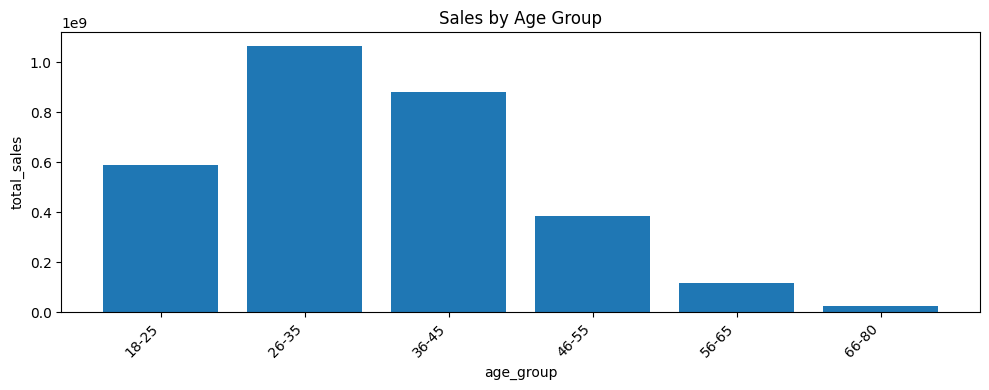

**Business Insight:**
- Age segmentation reveals which customer bands generate the most revenue.
- This can guide marketing and product positioning.

In [6]:
title = '5. GROUP BY — Sales by Age Group'
nlq = 'What is total sales amount by age group?'
sql = '''SELECT CASE WHEN age BETWEEN 18 AND 25 THEN '18-25' WHEN age BETWEEN 26 AND 35 THEN '26-35' WHEN age BETWEEN 36 AND 45 THEN '36-45' WHEN age BETWEEN 46 AND 55 THEN '46-55' WHEN age BETWEEN 56 AND 65 THEN '56-65' ELSE '66-80' END AS age_group, SUM(sales_amount) AS total_sales FROM sales GROUP BY age_group ORDER BY age_group;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
plot_result(df, kind='bar', x='age_group', y='total_sales', title='Sales by Age Group')
insight(['Age segmentation reveals which customer bands generate the most revenue.', 'This can guide marketing and product positioning.'])

## 6. GROUP BY — Transactions by Product

**Natural Language Question:** How many transactions are there for each product?

**SQL Query:**

```sql
SELECT product_name, COUNT(*) AS txn_count FROM sales GROUP BY product_name ORDER BY txn_count DESC;
```

,product_name,txn_count
0,COMPUTER,160236
1,LAPTOP,160195
2,TV,140236
3,EBIKE,109757
4,BIKE,99842
5,IPAD,99759
6,WATCH,80094
7,TABLE,59984
8,ROBOT,49867
9,RADIO,40030


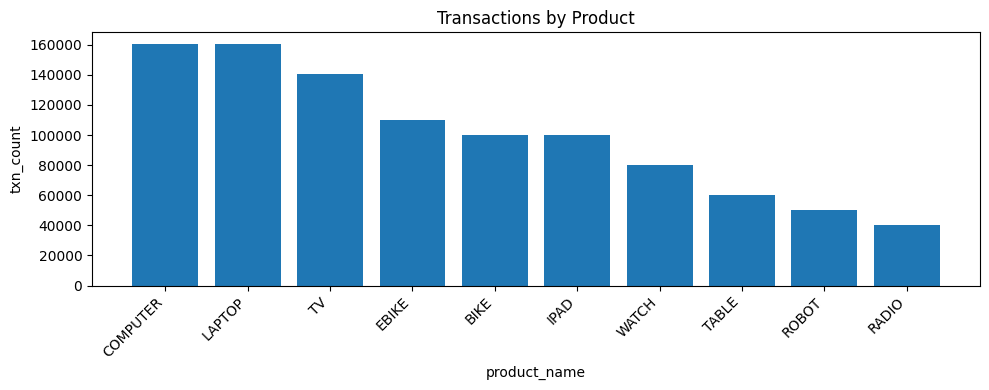

**Business Insight:**
- This reveals volume leaders, not necessarily revenue leaders.
- High-frequency products are operationally important.

In [7]:
title = '6. GROUP BY — Transactions by Product'
nlq = 'How many transactions are there for each product?'
sql = '''SELECT product_name, COUNT(*) AS txn_count FROM sales GROUP BY product_name ORDER BY txn_count DESC;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
plot_result(df, kind='bar', x='product_name', y='txn_count', title='Transactions by Product')
insight(['This reveals volume leaders, not necessarily revenue leaders.', 'High-frequency products are operationally important.'])

## 7. GROUP BY — Revenue by Product

**Natural Language Question:** What is total sales amount by product?

**SQL Query:**

```sql
SELECT product_name, SUM(sales_amount) AS total_sales FROM sales GROUP BY product_name ORDER BY total_sales DESC;
```

,product_name,total_sales
0,EBIKE,652723207.0
1,LAPTOP,626792022.0
2,COMPUTER,582575751.0
3,TV,393587461.0
4,ROBOT,222962493.0
5,BIKE,173987594.0
6,IPAD,161643729.0
7,WATCH,147770345.0
8,TABLE,88802348.0
9,RADIO,10608765.0


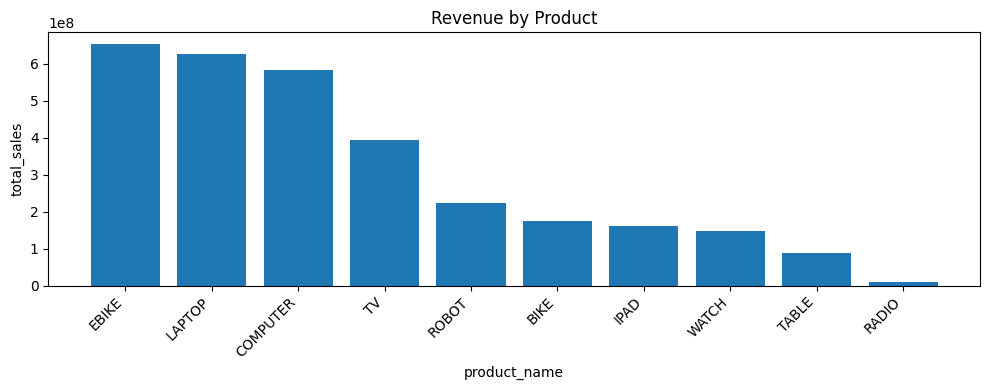

**Business Insight:**
- Premium categories may lead revenue even if their transaction count is lower.
- This helps compare frequency versus financial impact.

In [8]:
title = '7. GROUP BY — Revenue by Product'
nlq = 'What is total sales amount by product?'
sql = '''SELECT product_name, SUM(sales_amount) AS total_sales FROM sales GROUP BY product_name ORDER BY total_sales DESC;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
plot_result(df, kind='bar', x='product_name', y='total_sales', title='Revenue by Product')
insight(['Premium categories may lead revenue even if their transaction count is lower.', 'This helps compare frequency versus financial impact.'])

## 8. GROUP BY — Average Discount by Sale Type

**Natural Language Question:** What is the average discount by sale type?

**SQL Query:**

```sql
SELECT sale_type, AVG(discount) AS avg_discount FROM sales GROUP BY sale_type ORDER BY avg_discount DESC;
```

,sale_type,avg_discount
0,ONLINE,256.466367
1,INSTORE,221.140400


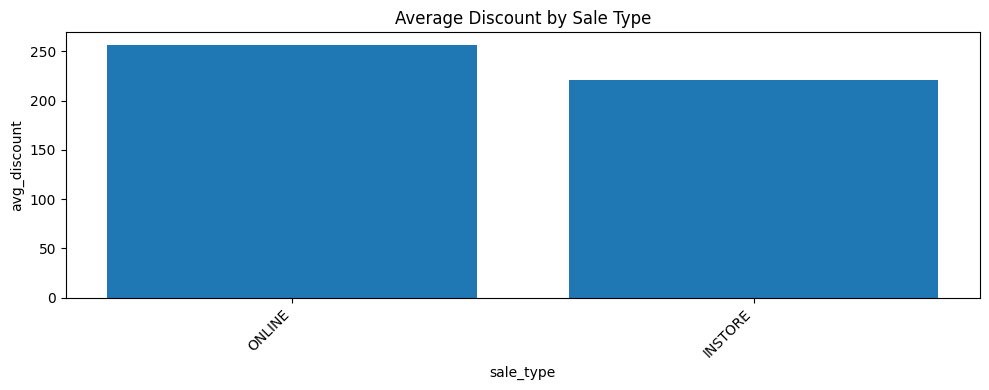

**Business Insight:**
- Online and in-store channels may use promotions differently.
- Discount behavior helps explain margin differences.

In [9]:
title = '8. GROUP BY — Average Discount by Sale Type'
nlq = 'What is the average discount by sale type?'
sql = '''SELECT sale_type, AVG(discount) AS avg_discount FROM sales GROUP BY sale_type ORDER BY avg_discount DESC;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
plot_result(df, kind='bar', x='sale_type', y='avg_discount', title='Average Discount by Sale Type')
insight(['Online and in-store channels may use promotions differently.', 'Discount behavior helps explain margin differences.'])

In [10]:
title = '9. GROUP BY — Revenue by Sale Type and Country'
nlq = 'What is total sales amount by sale type and country?'
sql = '''SELECT country, sale_type, SUM(sales_amount) AS total_sales FROM sales GROUP BY country, sale_type ORDER BY country, total_sales DESC;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
insight(['This shows how channel mix varies by market.', 'It helps identify countries where online or in-store dominates value creation.'])

## 9. GROUP BY — Revenue by Sale Type and Country

**Natural Language Question:** What is total sales amount by sale type and country?

**SQL Query:**

```sql
SELECT country, sale_type, SUM(sales_amount) AS total_sales FROM sales GROUP BY country, sale_type ORDER BY country, total_sales DESC;
```

,country,sale_type,total_sales
0,CANADA,ONLINE,130690851.0
1,CANADA,INSTORE,113345119.0
2,CHINA,ONLINE,197471572.0
3,CHINA,INSTORE,168420955.0
4,FRANCE,INSTORE,92002572.0
5,FRANCE,ONLINE,91233658.0
6,GERMANY,ONLINE,161268594.0
7,GERMANY,INSTORE,144762364.0
8,INDIA,ONLINE,190134373.0
9,INDIA,INSTORE,177801717.0


**Business Insight:**
- This shows how channel mix varies by market.
- It helps identify countries where online or in-store dominates value creation.

## 10. GROUP BY — Average Basket Value by Country

**Natural Language Question:** What is the average sales amount per transaction by country?

**SQL Query:**

```sql
SELECT country, AVG(sales_amount) AS avg_sales_amount FROM sales GROUP BY country ORDER BY avg_sales_amount DESC;
```

,country,avg_sales_amount
0,ITALY,3077.566839
1,MEXICO,3069.167458
2,SPAIN,3065.748533
3,GERMANY,3065.490259
4,FRANCE,3065.227421
5,INDIA,3059.963158
6,CANADA,3058.286484
7,USA,3058.199378
8,CHINA,3054.628178


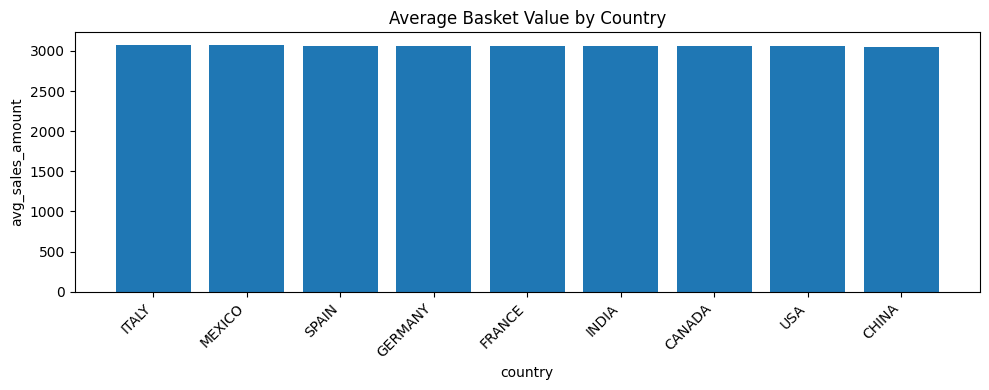

**Business Insight:**
- A smaller market can still have a larger average basket.
- This helps separate volume from transaction quality.

In [11]:
title = '10. GROUP BY — Average Basket Value by Country'
nlq = 'What is the average sales amount per transaction by country?'
sql = '''SELECT country, AVG(sales_amount) AS avg_sales_amount FROM sales GROUP BY country ORDER BY avg_sales_amount DESC;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
plot_result(df, kind='bar', x='country', y='avg_sales_amount', title='Average Basket Value by Country')
insight(['A smaller market can still have a larger average basket.', 'This helps separate volume from transaction quality.'])

## 11. Top-N — Top 5 Most Expensive Transactions

**Natural Language Question:** What are the top 5 most expensive transactions by sales amount?

**SQL Query:**

```sql
SELECT transaction_id, transaction_date, product_name, country, sales_amount FROM sales ORDER BY sales_amount DESC LIMIT 5;
```

,transaction_id,transaction_date,product_name,country,sales_amount
0,55833,2026-03-02 09:48:01,EBIKE,SPAIN,21594
1,7682,2026-02-27 16:40:36,EBIKE,SPAIN,21511
2,52904,2026-03-10 14:58:44,EBIKE,CHINA,21459
3,63445,2025-08-13 16:18:17,EBIKE,MEXICO,21380
4,18116,2026-03-20 10:08:23,EBIKE,USA,21289


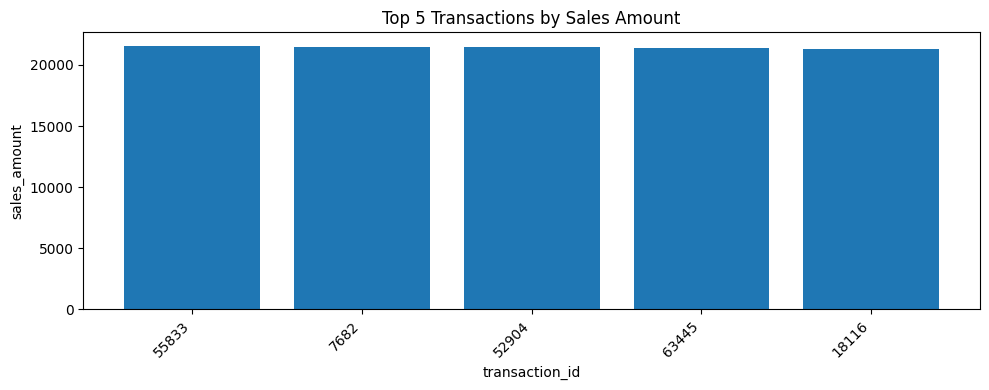

**Business Insight:**
- These transactions show the extreme upper tail of the dataset.
- High-ticket orders often come from expensive products and larger quantities.

In [12]:
title = '11. Top-N — Top 5 Most Expensive Transactions'
nlq = 'What are the top 5 most expensive transactions by sales amount?'
sql = '''SELECT transaction_id, transaction_date, product_name, country, sales_amount FROM sales ORDER BY sales_amount DESC LIMIT 5;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
plot_result(df, kind='bar', x='transaction_id', y='sales_amount', title='Top 5 Transactions by Sales Amount')
insight(['These transactions show the extreme upper tail of the dataset.', 'High-ticket orders often come from expensive products and larger quantities.'])

## 12. Top-N — Top 5 Products by Revenue

**Natural Language Question:** Which are the top 5 products by total sales amount?

**SQL Query:**

```sql
SELECT product_name, SUM(sales_amount) AS total_sales FROM sales GROUP BY product_name ORDER BY total_sales DESC LIMIT 5;
```

,product_name,total_sales
0,EBIKE,652723207.0
1,LAPTOP,626792022.0
2,COMPUTER,582575751.0
3,TV,393587461.0
4,ROBOT,222962493.0


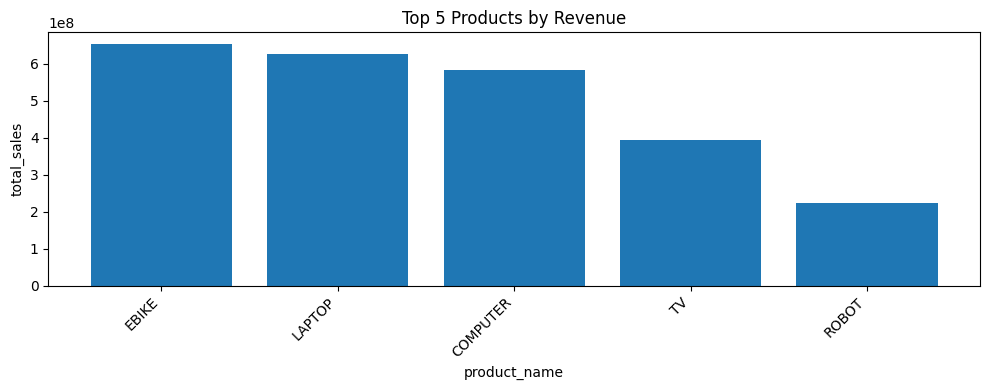

**Business Insight:**
- Top revenue products deserve close planning and forecasting attention.
- This is a high-value product ranking KPI.

In [13]:
title = '12. Top-N — Top 5 Products by Revenue'
nlq = 'Which are the top 5 products by total sales amount?'
sql = '''SELECT product_name, SUM(sales_amount) AS total_sales FROM sales GROUP BY product_name ORDER BY total_sales DESC LIMIT 5;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
plot_result(df, kind='bar', x='product_name', y='total_sales', title='Top 5 Products by Revenue')
insight(['Top revenue products deserve close planning and forecasting attention.', 'This is a high-value product ranking KPI.'])

In [14]:
title = '13. Top-N — Top 3 Countries per Year by Revenue'
nlq = 'For each year, what are the top 3 countries by revenue?'
sql = '''SELECT sale_year, country, total_sales FROM ( SELECT EXTRACT(YEAR FROM transaction_date) AS sale_year, country, SUM(sales_amount) AS total_sales, ROW_NUMBER() OVER (PARTITION BY EXTRACT(YEAR FROM transaction_date) ORDER BY SUM(sales_amount) DESC) AS rn FROM sales GROUP BY sale_year, country ) t WHERE rn <= 3 ORDER BY sale_year, total_sales DESC;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
insight(['This shows whether the same countries dominate every year.', 'Per-group top-N queries are essential for dimensional analytics.'])

## 13. Top-N — Top 3 Countries per Year by Revenue

**Natural Language Question:** For each year, what are the top 3 countries by revenue?

**SQL Query:**

```sql
SELECT sale_year, country, total_sales FROM ( SELECT EXTRACT(YEAR FROM transaction_date) AS sale_year, country, SUM(sales_amount) AS total_sales, ROW_NUMBER() OVER (PARTITION BY EXTRACT(YEAR FROM transaction_date) ORDER BY SUM(sales_amount) DESC) AS rn FROM sales GROUP BY sale_year, country ) t WHERE rn <= 3 ORDER BY sale_year, total_sales DESC;
```

,sale_year,country,total_sales
0,2023,USA,101384768.0
1,2023,INDIA,35707006.0
2,2023,CHINA,35146652.0
3,2024,USA,203961042.0
4,2024,INDIA,73210952.0
5,2024,CHINA,72206772.0
6,2025,USA,415804830.0
7,2025,CHINA,147672437.0
8,2025,INDIA,146331241.0
9,2026,USA,318429191.0


**Business Insight:**
- This shows whether the same countries dominate every year.
- Per-group top-N queries are essential for dimensional analytics.

In [15]:
title = '14. Top-N — Top 2 Products per Country by Transaction Count'
nlq = 'For each country, what are the top 2 products by transaction count?'
sql = '''SELECT country, product_name, txn_count FROM ( SELECT country, product_name, COUNT(*) AS txn_count, ROW_NUMBER() OVER (PARTITION BY country ORDER BY COUNT(*) DESC) AS rn FROM sales GROUP BY country, product_name ) t WHERE rn <= 2 ORDER BY country, txn_count DESC;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
insight(['Different markets often prefer different products.', 'This helps tailor local assortment and promotions.'])

## 14. Top-N — Top 2 Products per Country by Transaction Count

**Natural Language Question:** For each country, what are the top 2 products by transaction count?

**SQL Query:**

```sql
SELECT country, product_name, txn_count FROM ( SELECT country, product_name, COUNT(*) AS txn_count, ROW_NUMBER() OVER (PARTITION BY country ORDER BY COUNT(*) DESC) AS rn FROM sales GROUP BY country, product_name ) t WHERE rn <= 2 ORDER BY country, txn_count DESC;
```

,country,product_name,txn_count
0,CANADA,LAPTOP,12951
1,CANADA,COMPUTER,12883
2,CHINA,LAPTOP,19289
3,CHINA,COMPUTER,18964
4,FRANCE,COMPUTER,9736
5,FRANCE,LAPTOP,9521
6,GERMANY,COMPUTER,16184
7,GERMANY,LAPTOP,16019
8,INDIA,LAPTOP,19290
9,INDIA,COMPUTER,19170


**Business Insight:**
- Different markets often prefer different products.
- This helps tailor local assortment and promotions.

## 15. Top-N — Top 5 Months by Revenue

**Natural Language Question:** What are the top 5 months by revenue across the dataset?

**SQL Query:**

```sql
SELECT EXTRACT(MONTH FROM transaction_date) AS sale_month, SUM(sales_amount) AS total_sales FROM sales GROUP BY sale_month ORDER BY total_sales DESC LIMIT 5;
```

,sale_month,total_sales
0,3,562632268.0
1,2,428817185.0
2,1,410628198.0
3,12,234406392.0
4,11,210922369.0


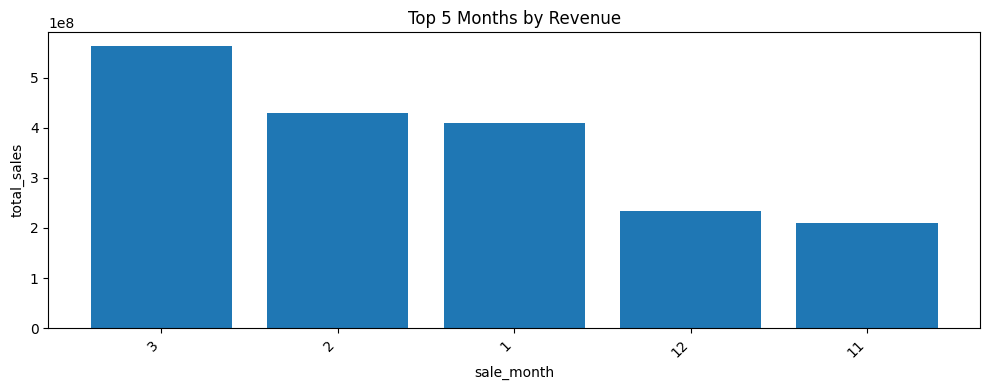

**Business Insight:**
- Best-performing months are useful for promotion timing and inventory planning.
- This highlights seasonality from a revenue perspective.

In [16]:
title = '15. Top-N — Top 5 Months by Revenue'
nlq = 'What are the top 5 months by revenue across the dataset?'
sql = '''SELECT EXTRACT(MONTH FROM transaction_date) AS sale_month, SUM(sales_amount) AS total_sales FROM sales GROUP BY sale_month ORDER BY total_sales DESC LIMIT 5;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
plot_result(df, kind='bar', x='sale_month', y='total_sales', title='Top 5 Months by Revenue')
insight(['Best-performing months are useful for promotion timing and inventory planning.', 'This highlights seasonality from a revenue perspective.'])

## 16. Business Query — Revenue by Price Band

**Natural Language Question:** How is revenue distributed across price bands?

**SQL Query:**

```sql
SELECT CASE WHEN price < 100 THEN 'Under 100' WHEN price < 500 THEN '100-499' WHEN price < 1000 THEN '500-999' WHEN price < 2000 THEN '1000-1999' ELSE '2000+' END AS price_band, SUM(sales_amount) AS total_sales FROM sales GROUP BY price_band ORDER BY total_sales DESC;
```

,price_band,total_sales
0,2000+,1.828694e+09
1,1000-1999,9.493721e+08
2,500-999,2.515616e+08
3,100-499,3.092100e+07
4,Under 100,9.050830e+05


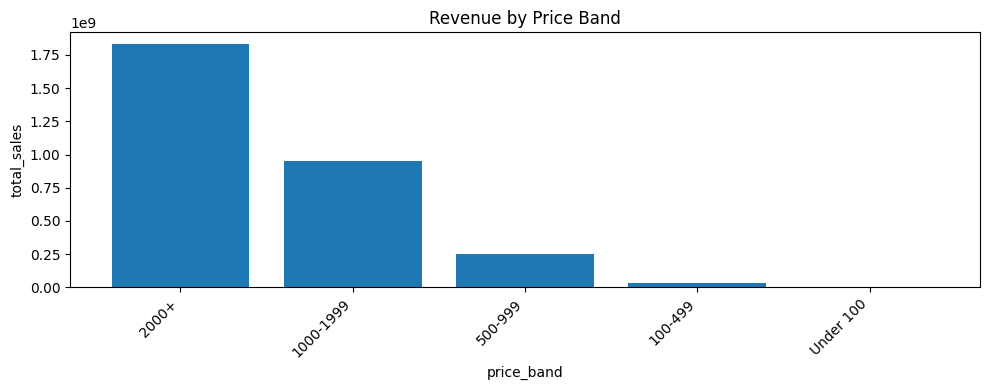

**Business Insight:**
- Price-band analysis shows whether the business is volume-driven or premium-driven.
- It can help frame assortment and positioning strategy.

In [17]:
title = '16. Business Query — Revenue by Price Band'
nlq = 'How is revenue distributed across price bands?'
sql = '''SELECT CASE WHEN price < 100 THEN 'Under 100' WHEN price < 500 THEN '100-499' WHEN price < 1000 THEN '500-999' WHEN price < 2000 THEN '1000-1999' ELSE '2000+' END AS price_band, SUM(sales_amount) AS total_sales FROM sales GROUP BY price_band ORDER BY total_sales DESC;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
plot_result(df, kind='bar', x='price_band', y='total_sales', title='Revenue by Price Band')
insight(['Price-band analysis shows whether the business is volume-driven or premium-driven.', 'It can help frame assortment and positioning strategy.'])

## 17. Business Query — Revenue by Quantity

**Natural Language Question:** What is the total sales amount by quantity purchased?

**SQL Query:**

```sql
SELECT quantity, SUM(sales_amount) AS total_sales FROM sales GROUP BY quantity ORDER BY quantity;
```

,quantity,total_sales
0,1,743121027.0
1,2,906343772.0
2,3,827176583.0
3,4,584812333.0


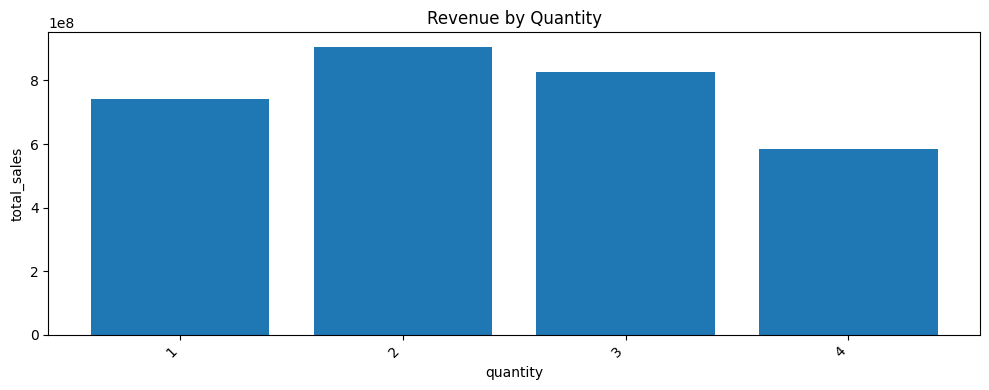

**Business Insight:**
- Higher-quantity orders may contribute outsized revenue.
- This helps understand order-size behavior and bundling opportunities.

In [18]:
title = '17. Business Query — Revenue by Quantity'
nlq = 'What is the total sales amount by quantity purchased?'
sql = '''SELECT quantity, SUM(sales_amount) AS total_sales FROM sales GROUP BY quantity ORDER BY quantity;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
plot_result(df, kind='bar', x='quantity', y='total_sales', title='Revenue by Quantity')
insight(['Higher-quantity orders may contribute outsized revenue.', 'This helps understand order-size behavior and bundling opportunities.'])

## 18. Business Query — Average Discount by Product

**Natural Language Question:** Which products receive the highest average discount?

**SQL Query:**

```sql
SELECT product_name, AVG(discount) AS avg_discount FROM sales GROUP BY product_name ORDER BY avg_discount DESC;
```

,product_name,avg_discount
0,EBIKE,470.980575
1,ROBOT,362.533880
2,LAPTOP,316.038010
3,COMPUTER,291.986701
4,TV,220.760589
5,IPAD,130.421736
6,WATCH,126.098821
7,BIKE,118.621812
8,TABLE,100.047979
9,RADIO,17.873270


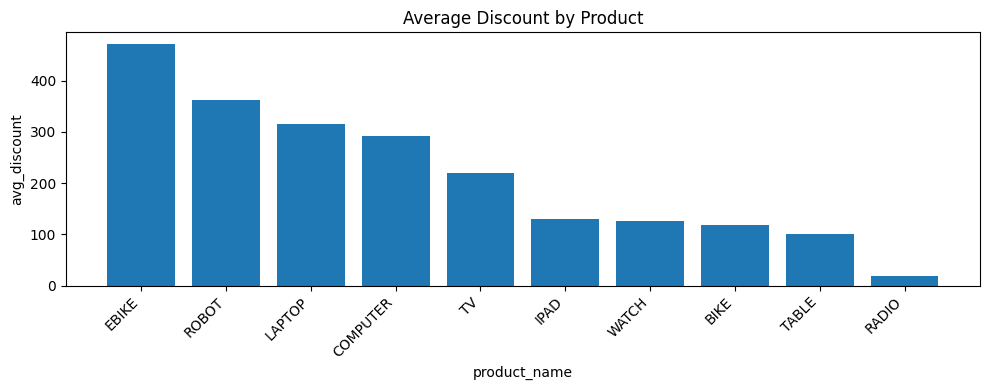

**Business Insight:**
- Some categories may rely more heavily on discounting to drive demand.
- This can prompt margin and promotion review.

In [19]:
title = '18. Business Query — Average Discount by Product'
nlq = 'Which products receive the highest average discount?'
sql = '''SELECT product_name, AVG(discount) AS avg_discount FROM sales GROUP BY product_name ORDER BY avg_discount DESC;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
plot_result(df, kind='bar', x='product_name', y='avg_discount', title='Average Discount by Product')
insight(['Some categories may rely more heavily on discounting to drive demand.', 'This can prompt margin and promotion review.'])

In [20]:
title = '19. Business Query — Revenue by Country and Gender'
nlq = 'How much revenue comes from each country-gender combination?'
sql = '''SELECT country, gender, SUM(sales_amount) AS total_sales FROM sales GROUP BY country, gender ORDER BY country, total_sales DESC;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
insight(['This combines demographic and geographic slices for richer segmentation.', 'It can reveal market-specific customer composition.'])

## 19. Business Query — Revenue by Country and Gender

**Natural Language Question:** How much revenue comes from each country-gender combination?

**SQL Query:**

```sql
SELECT country, gender, SUM(sales_amount) AS total_sales FROM sales GROUP BY country, gender ORDER BY country, total_sales DESC;
```

,country,gender,total_sales
0,CANADA,FEMALE,151958684.0
1,CANADA,MALE,92077286.0
2,CHINA,FEMALE,229376511.0
3,CHINA,MALE,136516016.0
4,FRANCE,FEMALE,113774900.0
5,FRANCE,MALE,69461330.0
6,GERMANY,FEMALE,190152271.0
7,GERMANY,MALE,115878687.0
8,INDIA,FEMALE,228997149.0
9,INDIA,MALE,138938941.0


**Business Insight:**
- This combines demographic and geographic slices for richer segmentation.
- It can reveal market-specific customer composition.

## 20. Business Query — Monthly Sales for 2026 Q1

**Natural Language Question:** How do sales trend across January, February, and March of 2026?

**SQL Query:**

```sql
SELECT EXTRACT(MONTH FROM transaction_date) AS sale_month, SUM(sales_amount) AS total_sales FROM sales WHERE EXTRACT(YEAR FROM transaction_date) = 2026 GROUP BY sale_month ORDER BY sale_month;
```

,sale_month,total_sales
0,1,260927588.0
1,2,279798358.0
2,3,394037507.0


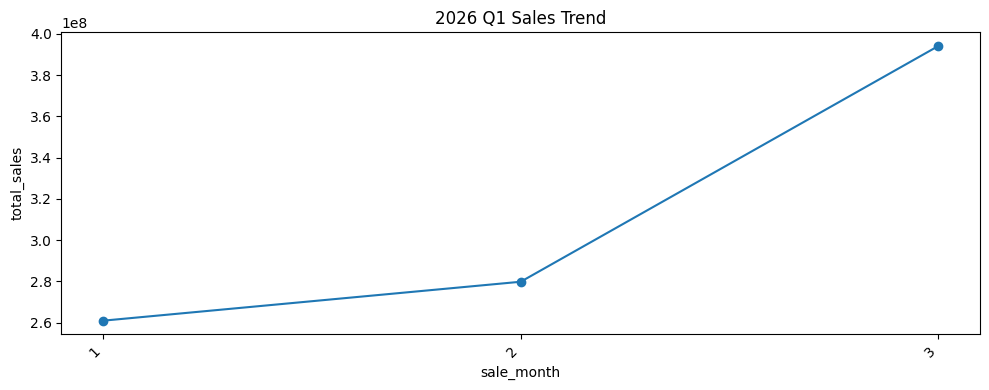

**Business Insight:**
- This isolates the intentionally partial-year 2026 file.
- Short-window time analysis is useful for quarter-level business monitoring.

In [21]:
title = '20. Business Query — Monthly Sales for 2026 Q1'
nlq = 'How do sales trend across January, February, and March of 2026?'
sql = '''SELECT EXTRACT(MONTH FROM transaction_date) AS sale_month, SUM(sales_amount) AS total_sales FROM sales WHERE EXTRACT(YEAR FROM transaction_date) = 2026 GROUP BY sale_month ORDER BY sale_month;'''
show_query_block(title, nlq, sql)
df = run_query(sql)
plot_result(df, kind='line', x='sale_month', y='total_sales', title='2026 Q1 Sales Trend')
insight(['This isolates the intentionally partial-year 2026 file.', 'Short-window time analysis is useful for quarter-level business monitoring.'])

---
# 21. Pie Chart — Revenue Share by Product"
### What percentage of total revenue comes from each product?

## 21. Pie Chart — Revenue Share by Product

**Natural Language Question:** What percentage of total revenue comes from each product?

**SQL Query:**

```sql

SELECT 
    product_name,
    SUM(sales_amount) AS total_sales
FROM sales
GROUP BY product_name
ORDER BY total_sales DESC;

```

,product_name,total_sales
0,EBIKE,652723207.0
1,LAPTOP,626792022.0
2,COMPUTER,582575751.0
3,TV,393587461.0
4,ROBOT,222962493.0
5,BIKE,173987594.0
6,IPAD,161643729.0
7,WATCH,147770345.0
8,TABLE,88802348.0
9,RADIO,10608765.0


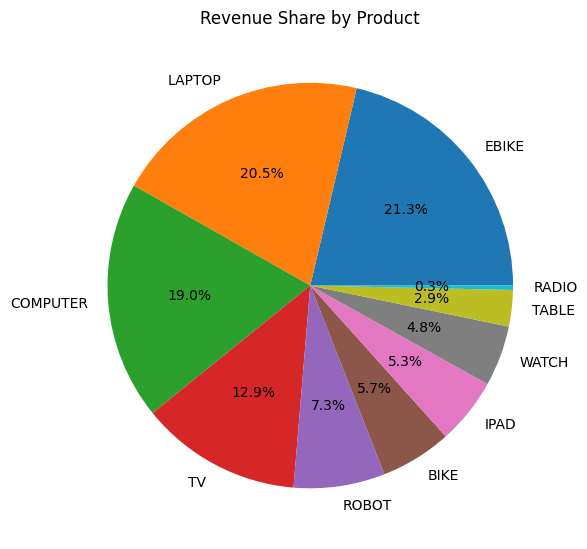

**Business Insight:**
- This shows which products dominate total revenue contribution.
- If a few products take most of the share, the business is highly concentrated.

In [22]:
title = "21. Pie Chart — Revenue Share by Product"
nlq = "What percentage of total revenue comes from each product?"

sql = """
SELECT 
    product_name,
    SUM(sales_amount) AS total_sales
FROM sales
GROUP BY product_name
ORDER BY total_sales DESC;
"""

show_query_block(title, nlq, sql)
df = run_query(sql)

# Pie Chart
plt.figure(figsize=(6,6))
plt.pie(
    df["total_sales"],
    labels=df["product_name"],
    autopct='%1.1f%%'
)
plt.title("Revenue Share by Product")
plt.tight_layout()
plt.show()

insight([
    "This shows which products dominate total revenue contribution.",
    "If a few products take most of the share, the business is highly concentrated."
])

---
# Cell 22 — Revenue Share by Country
### What percentage of total revenue comes from each country?

## 22. Pie Chart — Revenue Share by Country

**Natural Language Question:** What percentage of total revenue comes from each country?

**SQL Query:**

```sql

SELECT 
    country,
    SUM(sales_amount) AS total_sales
FROM sales
GROUP BY country
ORDER BY total_sales DESC;

```

,country,total_sales
0,USA,1.039580e+09
1,INDIA,3.679361e+08
2,CHINA,3.658925e+08
3,GERMANY,3.060310e+08
4,CANADA,2.440360e+08
5,MEXICO,2.153727e+08
6,ITALY,1.852818e+08
7,FRANCE,1.832362e+08
8,SPAIN,1.540876e+08


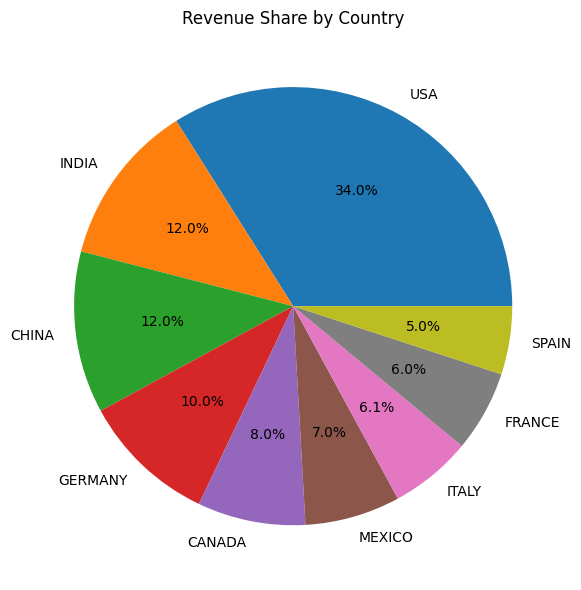

**Business Insight:**
- USA should dominate due to the designed data distribution.
- This highlights geographic concentration risk and opportunity.